# Electricity price floor & asymmetry techniques comparison

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

current_dir = Path.cwd()
project_root = None
if (current_dir / 'config.py').exists():
    project_root = str(current_dir)
elif (current_dir.parent / 'config.py').exists():
    project_root = str(current_dir.parent)

if project_root and project_root not in sys.path:
    sys.path.insert(0, project_root)

from models import (
    ProbabilisticTransformer,
    HybridProbabilisticTransformer,
    HybridProbabilisticTransformerReflectedOU,
    HybridProbabilisticTransformerCIR,
    HybridProbabilisticTransformerPostHocFloor,
)
from core.experiment_utils import (
    load_data, load_cache, save_cache, run_experiment, N_RUNS,
)

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

try:
    gpus = tf.config.experimental.list_physical_devices("GPU")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPUs detected: {len(gpus)}")
except Exception as e:
    print(f"GPU config failed: {e}")

2026-03-06 07:05:01.968113: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772777102.060409 3174659 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772777102.089421 3174659 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772777102.270187 3174659 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772777102.270213 3174659 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772777102.270217 3174659 computation_placer.cc:177] computation placer alr

GPUs detected: 1


In [2]:
RESULTS_DIR = Path(project_root) / "results" / "price_floor_comparison"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = RESULTS_DIR / "results.json"

In [3]:
# All metrics and caching handled by core.experiment_utils

In [4]:
data = load_data()

Loading Data...
Train: (19509, 168, 28), Test: (13087, 168, 28)


In [5]:
# Model configurations: (display_name, model_class, head_type, head_params, is_hybrid, apply_posthoc_floor)
MODEL_CONFIGS = [
    ("Baseline (Gaussian)", ProbabilisticTransformer, "gaussian", {}, False, False),
    ("Baseline (Johnson SU)", ProbabilisticTransformer, "johnson_su", {}, False, False),
    ("Johnson SU + Floor", ProbabilisticTransformer, "johnson_su_floor", {"floor_penalty_weight": 0.1, "asymmetric_weight": 1.5}, False, False),
    ("Truncated Normal", ProbabilisticTransformer, "truncated_normal", {}, False, False),
    ("Transformer + PostHoc Floor", ProbabilisticTransformer, "johnson_su", {}, False, True),
    ("Hybrid (Transformer+OU)", HybridProbabilisticTransformer, "johnson_su", {}, True, False),
    ("Hybrid + Reflected OU", HybridProbabilisticTransformerReflectedOU, "johnson_su", {}, True, False),
    ("Hybrid + CIR", HybridProbabilisticTransformerCIR, "johnson_su", {}, True, False),
    ("Hybrid + PostHoc Floor", HybridProbabilisticTransformerPostHocFloor, "johnson_su", {}, True, False),
]

In [6]:
cache = load_cache(CACHE_FILE)

for model_name, model_cls, head_type, head_params, is_hybrid, apply_posthoc_floor in MODEL_CONFIGS:
    run_experiment(
        model_cls, model_name, data,
        str(RESULTS_DIR),
        cache=cache,
        is_hybrid=is_hybrid,
        head_type=head_type,
        head_params=head_params,
    )

save_cache(CACHE_FILE, cache)
print("\nAll experiments complete.")

Results for Baseline (Gaussian) found in cache. Skipping.
Results for Baseline (Johnson SU) found in cache. Skipping.

Running: Johnson SU + Floor
  Run 1/5...


I0000 00:00:1772777108.412196 3174659 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7483 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080, pci bus id: 0000:01:00.0, compute capability: 6.1


Epoch 1/30


I0000 00:00:1772777115.154146 3174884 service.cc:152] XLA service 0x72b144003a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772777115.154163 3174884 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1080, Compute Capability 6.1
2026-03-06 07:05:15.354237: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1772777116.393241 3174884 cuda_dnn.cc:529] Loaded cuDNN version 90300


  4/305 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - loss: 1.8654

I0000 00:00:1772777124.195044 3174884 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


305/305 ━━━━━━━━━━━━━━━━━━━━ 41s 86ms/step - loss: 1.0742 - val_loss: 1.0116 - learning_rate: 7.0000e-04
Epoch 2/30
305/305 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - loss: 0.7355 - val_loss: 0.9055 - learning_rate: 7.0000e-04
Epoch 3/30
305/305 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - loss: 0.6034 - val_loss: 0.8878 - learning_rate: 7.0000e-04
Epoch 4/30
305/305 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - loss: 0.5022 - val_loss: 1.0111 - learning_rate: 7.0000e-04
Epoch 5/30
305/305 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - loss: 0.4272 - val_loss: 1.2872 - learning_rate: 7.0000e-04
Epoch 6/30
305/305 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - loss: 0.3601 - val_loss: 1.0945 - learning_rate: 7.0000e-04
Epoch 7/30
305/305 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - loss: 0.3097 - val_loss: 1.0646 - learning_rate: 7.0000e-04
Epoch 8/30
305/305 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - loss: 0.2637 - val_loss: 1.4047 - learning_rate: 7.0000e-04
  Run 2/5...
Epoch 1/30
305/305 ━━━━━━━━━━━━━━━━━━━━ 39s 82ms/step - loss: 1.4265 -

KeyboardInterrupt: 

In [7]:
# Results summary
results = []
for model_name, metrics in cache.items():
    results.append({"Model": model_name, **metrics})

df_res = pd.DataFrame(results)
if not df_res.empty:
    df_sorted = df_res.sort_values("MAE")
    display(df_sorted)
    df_sorted.to_csv(RESULTS_DIR / "comparison_summary.csv", index=False)
    print(f"\nResults saved to {RESULTS_DIR / 'comparison_summary.csv'}")

,Model,MAE,RMSE,MAPE,R2,Pinball_10,Pinball_50,Pinball_90,Avg_Pinball,PICP,MPIW,PINAW,IntervalScore,CRPS
5,Hybrid (Transformer+OU),24.759456,33.148448,833.825593,0.167387,5.679624,12.159988,6.434376,8.091330,0.858806,97.509743,0.237585,197.715224,17.885839
0,Baseline (Gaussian),25.630207,33.516469,854.601010,0.149080,6.192554,12.815103,6.647018,8.551559,0.794279,81.782788,0.199266,222.204785,18.953907
1,Baseline (Johnson SU),25.693931,33.964027,865.387629,0.124359,6.529975,12.567782,7.176006,8.757921,0.770599,83.705415,0.203951,245.444678,19.123467
8,Hybrid + PostHoc Floor,25.741088,35.069046,2268.488310,0.069650,12.495605,12.750191,6.175230,10.473675,0.463899,49.539931,0.120705,587.354098,21.894068
7,Hybrid + CIR,25.857839,34.249758,869.177323,0.111998,7.003811,12.786828,6.663532,8.818057,0.778616,86.240452,0.210127,243.230949,19.250749
2,Johnson SU + Floor,25.948307,34.576259,893.648479,0.095572,6.695638,12.739049,7.510925,8.981871,0.745985,79.073787,0.192666,266.207220,19.534814
4,Transformer + PostHoc Floor,26.039347,35.337131,2265.723474,0.055236,12.865335,12.904065,6.943989,10.904463,0.402101,41.499062,0.101114,626.021754,22.634641
6,Hybrid + Reflected OU,26.456949,34.884190,943.656902,0.079402,8.085685,13.617071,6.439879,9.380878,0.766551,89.714920,0.218593,258.856463,20.482098
3,Truncated Normal,27.150791,36.843549,2314.058913,-0.027308,12.132780,12.943293,7.700344,10.925473,0.370234,44.558321,0.108568,656.325113,22.717469



Results saved to /home/d1ff1cult/masterproef_new/results/price_floor_comparison/comparison_summary.csv


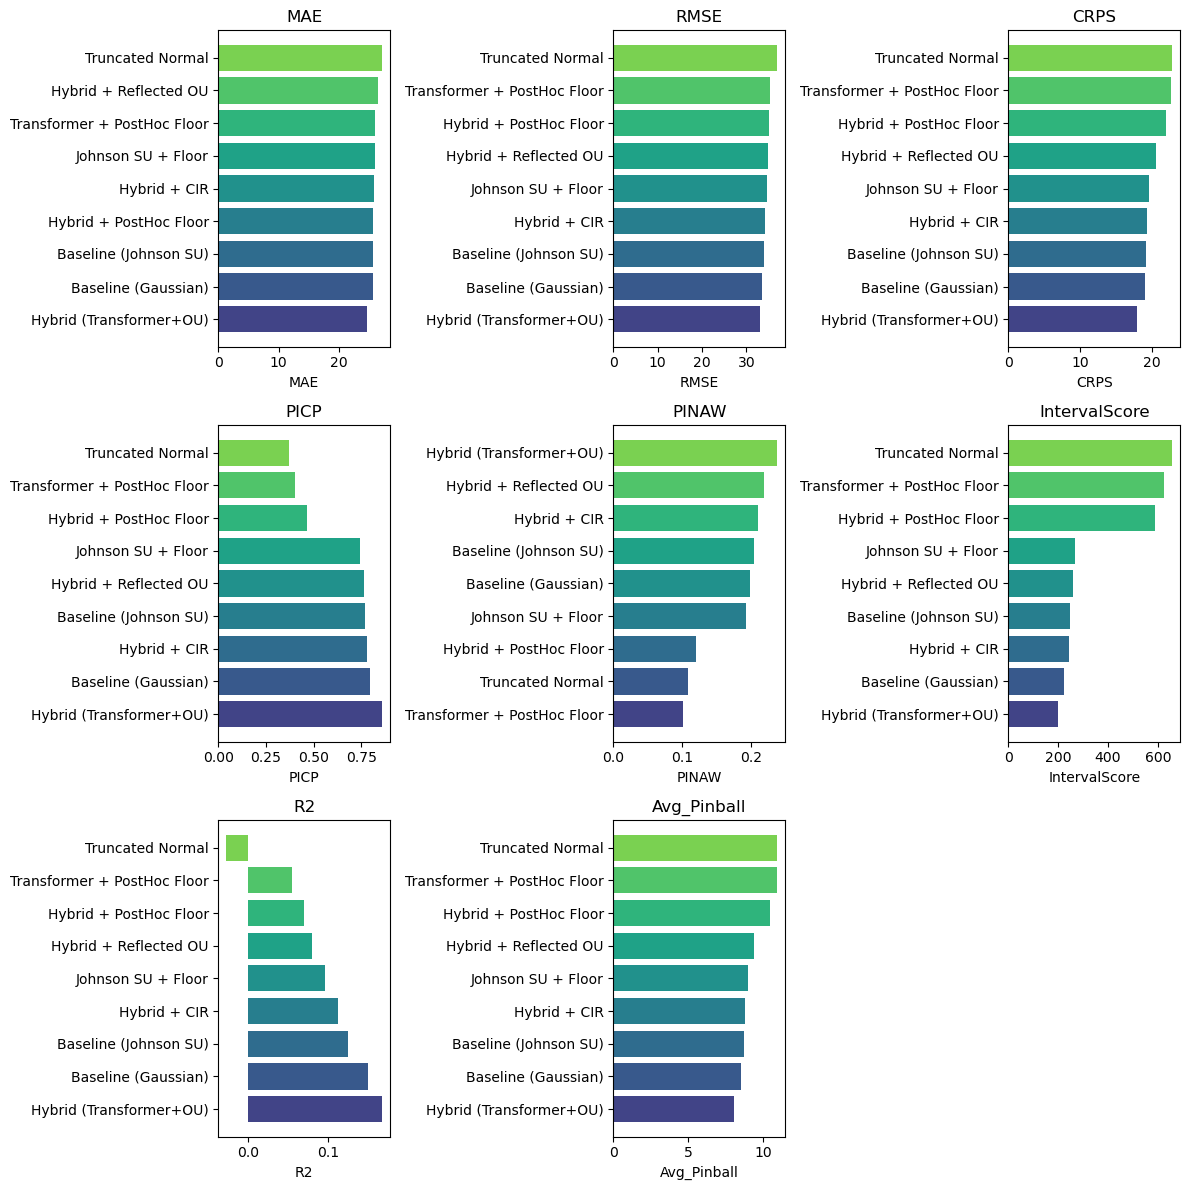

Plot saved to /home/d1ff1cult/masterproef_new/results/price_floor_comparison/comparison_charts.png


In [8]:
# Bar charts for key metrics
if not df_res.empty:
    import matplotlib.pyplot as plt

    metrics_to_plot = ["MAE", "RMSE", "CRPS", "PICP", "PINAW", "IntervalScore", "R2", "Avg_Pinball"]
    metrics_avail = [m for m in metrics_to_plot if m in df_res.columns]
    n_plots = len(metrics_avail)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    if n_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for ax, metric in zip(axes[:n_plots], metrics_avail):
        ascending = metric not in ("R2", "PICP")
        df_plot = df_res.sort_values(metric, ascending=ascending)
        colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(df_plot)))
        ax.barh(df_plot["Model"], df_plot[metric], color=colors)
        ax.set_xlabel(metric)
        ax.set_title(metric)

    for ax in axes[n_plots:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "comparison_charts.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved to {RESULTS_DIR / 'comparison_charts.png'}")